<a href="https://colab.research.google.com/github/LeeMin1101/NhanDienDoAn/blob/main/DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split
import os
import copy
import matplotlib.pyplot as plt
from PIL import Image
import glob

# Thiết lập thiết bị GPU nếu có
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Thiết bị đang sử dụng: {device}')

Thiết bị đang sử dụng: cuda


# Bước 2: Tải và chuẩn bị dữ liệu
Tải bộ dữ liệu Food101 (10% version). Thống kê số lượng ảnh huấn luyện và kiểm tra.

In [ ]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Tải dữ liệu Food101 (bản 10% để chạy nhanh)
if not os.path.exists('10_food_classes_10_percent'):
    !wget -q https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
    !unzip -q 10_food_classes_10_percent.zip

train_dir = '10_food_classes_10_percent/train'
test_dir = '10_food_classes_10_percent/test'

# Pipeline xử lý ảnh
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Gộp và chia lại data theo tỷ lệ 60/20/20
full_train_ds = datasets.ImageFolder(train_dir)
full_test_ds = datasets.ImageFolder(test_dir)
combined_dataset = torch.utils.data.ConcatDataset([full_train_ds, full_test_ds])
class_names = full_train_ds.classes

total_size = len(combined_dataset)
train_size = int(0.6 * total_size)
val_size = int(0.2 * total_size)
test_size = total_size - train_size - val_size

seed_gen = torch.Generator().manual_seed(42)
train_indices, val_indices, test_indices = random_split(
    combined_dataset, [train_size, val_size, test_size], generator=seed_gen
)

class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform: x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.subset)

image_datasets = {
    'train': ApplyTransform(train_indices, data_transforms['train']),
    'val': ApplyTransform(val_indices, data_transforms['val']),
    'test': ApplyTransform(test_indices, data_transforms['val'])
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=32, shuffle=(x=='train'), num_workers=2)
    for x in ['train', 'val', 'test']
}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}

print(f"Dataset: {class_names}")
print(f"Train: {dataset_sizes['train']}, Val: {dataset_sizes['val']}, Test: {dataset_sizes['test']}")

Dataset: ['chicken_curry', 'chicken_wings', 'fried_rice', 'grilled_salmon', 'hamburger', 'ice_cream', 'pizza', 'ramen', 'steak', 'sushi']
Train: 1950, Val: 650, Test: 650


# Bước 3: Cấu hình mô hình MobileNetV2
Sử dụng Fine-tuning: đóng băng các tầng đầu và huấn luyện lại các tầng sau để đạt độ chính xác cao nhất.

In [ ]:
model = models.mobilenet_v2(weights='DEFAULT')

# Fine-tuning: Chỉ huấn luyện các block cuối (từ block 14 trở đi)
for i, (name, param) in enumerate(model.features.named_parameters()):
    block_idx = int(name.split('.')[0])
    param.requires_grad = (block_idx >= 14)

# Thay đổi head classifier cho 10 lớp
model.classifier[1] = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.classifier[1].in_features, len(class_names))
)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.1)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 144MB/s]


# Bước 4: Hàm huấn luyện với Early Stopping
Hàm này sẽ thực hiện loop training, in log và tự động lưu mô hình tốt nhất.

In [ ]:
from tqdm.auto import tqdm

def train_model(model, criterion, optimizer, scheduler, num_epochs=20, patience=5):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')
    early_stop_counter = 0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')

        for phase in ['train', 'val']:
            if phase == 'train': model.train()
            else: model.eval()

            running_loss, running_corrects = 0.0, 0

            for inputs, labels in tqdm(dataloaders[phase], desc=phase, leave=False):
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val':
                scheduler.step(epoch_loss)
                if epoch_loss < best_loss:
                    best_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    early_stop_counter = 0
                else:
                    early_stop_counter += 1

        if early_stop_counter >= patience:
            print("Early stopping triggered!")
            break

    model.load_state_dict(best_model_wts)
    return model, history

In [ ]:
# Bắt đầu huấn luyện với Early Stopping và Fine-tuning
model, history = train_model(
    model,
    criterion,
    optimizer,
    scheduler,
    num_epochs=40,
    patience=5
)

# Lưu model sau khi train
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': class_names
}, 'food_model_v2.pth')

print("\u2705 Huấn luyện hoàn tất và đã lưu mô hình!")


Epoch 1/40


train Loss: 1.2923 Acc: 58.41%


val Loss: 0.6930 Acc: 78.00%
✅ New best model found and saved.

Epoch 2/40


train Loss: 0.7734 Acc: 74.21%


val Loss: 0.5107 Acc: 82.77%
✅ New best model found and saved.

Epoch 3/40


...

val Loss: 0.3320 Acc: 89.54%
⚠️ No improvement for 3 epochs.

Epoch 34/40


train Loss: 0.2068 Acc: 93.08%


val Loss: 0.3306 Acc: 89.54%
⚠️ No improvement for 4 epochs.

Epoch 35/40


train Loss: 0.2015 Acc: 93.49%


val Loss: 0.3444 Acc: 89.54%
⚠️ No improvement for 5 epochs.
⏹ Early stopping at epoch 35
✅ Huấn luyện hoàn tất và đã lưu mô hình!


# Bước 5: Trực quan hóa kết quả
Xuất biểu đồ Train/Val Loss và Accuracy để đánh giá chất lượng mô hình.

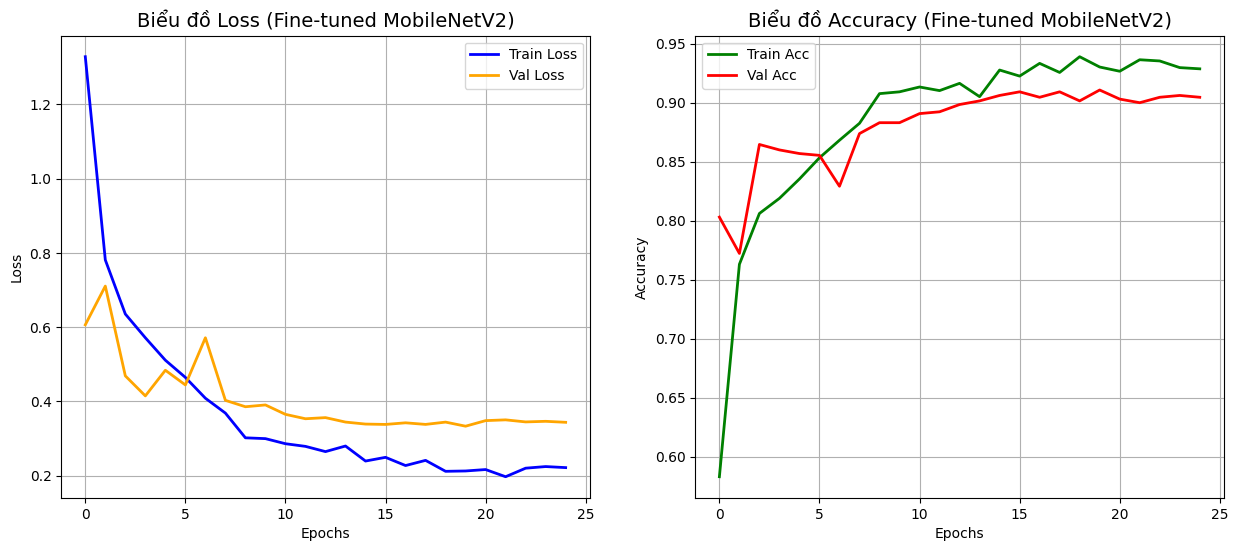

In [ ]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue', lw=2)
plt.plot(history['val_loss'], label='Val Loss', color='orange', lw=2)
plt.title('Biểu đồ Loss (Fine-tuned MobileNetV2)', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc', color='green', lw=2)
plt.plot(history['val_acc'], label='Val Acc', color='red', lw=2)
plt.title('Biểu đồ Accuracy (Fine-tuned MobileNetV2)', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Bước 6: Hàm dự đoán (Threshold > 50%)
Định nghĩa hàm nhận diện, chỉ chấp nhận kết quả nếu độ tin cậy > 50%.

In [ ]:
def predict_food(img_path):
    img = Image.open(img_path).convert('RGB')
    img_t = data_transforms['val'](img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        outputs = model(img_t)
        probs = torch.nn.functional.softmax(outputs[0], dim=0)
        conf, idx = torch.max(probs, 0)

    result_label = class_names[idx.item()]
    result_conf = conf.item() * 100

    if result_conf > 50:
        return result_label, result_conf
    else:
        return "Không xác định (Độ tin cậy thấp)", result_conf

# Bước 7: Kiểm tra thực tế
Chọn ngẫu nhiên một ảnh từ tập Test để kiểm chứng.

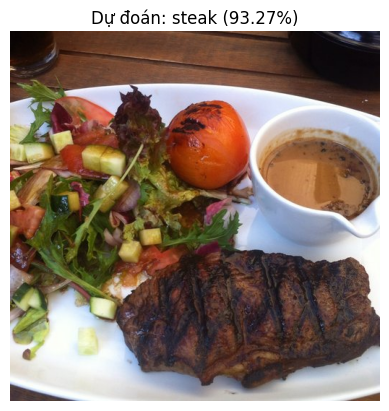

In [ ]:
import random

# Chọn ngẫu nhiên một ảnh từ tập Test để kiểm chứng
test_images = glob.glob(test_dir + '/*/*.jpg')

if test_images:
    sample_path = random.choice(test_images)
    label, score = predict_food(sample_path)

    plt.imshow(Image.open(sample_path))
    plt.title(f'Dự đoán: {label} ({score:.2f}%)')
    plt.axis('off')
    plt.show()
else:
    print("Không tìm thấy ảnh trong thư mục test.")